# Notebook 04: Time Series Decomposition
Decomposes monthly sales into trend, seasonality, and residual components to understand underlying patterns before forecasting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.seasonal import seasonal_decompose
import os

os.makedirs("../outputs/figures", exist_ok=True)

# Load cleaned data
df = pd.read_csv("../data/processed/cleaned_data.csv", encoding="latin-1")
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Aggregate to monthly sales
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
    .sort_index()
)
monthly_sales.index = monthly_sales.index.to_timestamp()

print("Monthly series length:", len(monthly_sales))
print("\nDate range:", monthly_sales.index[0], "to", monthly_sales.index[-1])
print("\nFirst 6 months:")
print(monthly_sales.head(6))

Monthly series length: 48

Date range: 2014-01-01 00:00:00 to 2017-12-01 00:00:00

First 6 months:
Order Date
2014-01-01    14236.8950
2014-02-01     4519.8920
2014-03-01    55691.0090
2014-04-01    28295.3450
2014-05-01    23648.2870
2014-06-01    34595.1276
Freq: MS, Name: Sales, dtype: float64


In [2]:
# Decompose the time series
# period=12 because we have monthly data with yearly seasonality
decomposition = seasonal_decompose(monthly_sales, model="additive", period=12)

trend    = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

print("Decomposition complete.")
print(f"\nTrend range:    ${trend.dropna().min():,.0f} to ${trend.dropna().max():,.0f}")
print(f"Seasonal range: ${seasonal.min():,.0f} to ${seasonal.max():,.0f}")
print(f"Residual std:   ${residual.dropna().std():,.0f}")

Decomposition complete.

Trend range:    $38,874 to $61,650
Seasonal range: $-28,142 to $34,995
Residual std:   $6,691


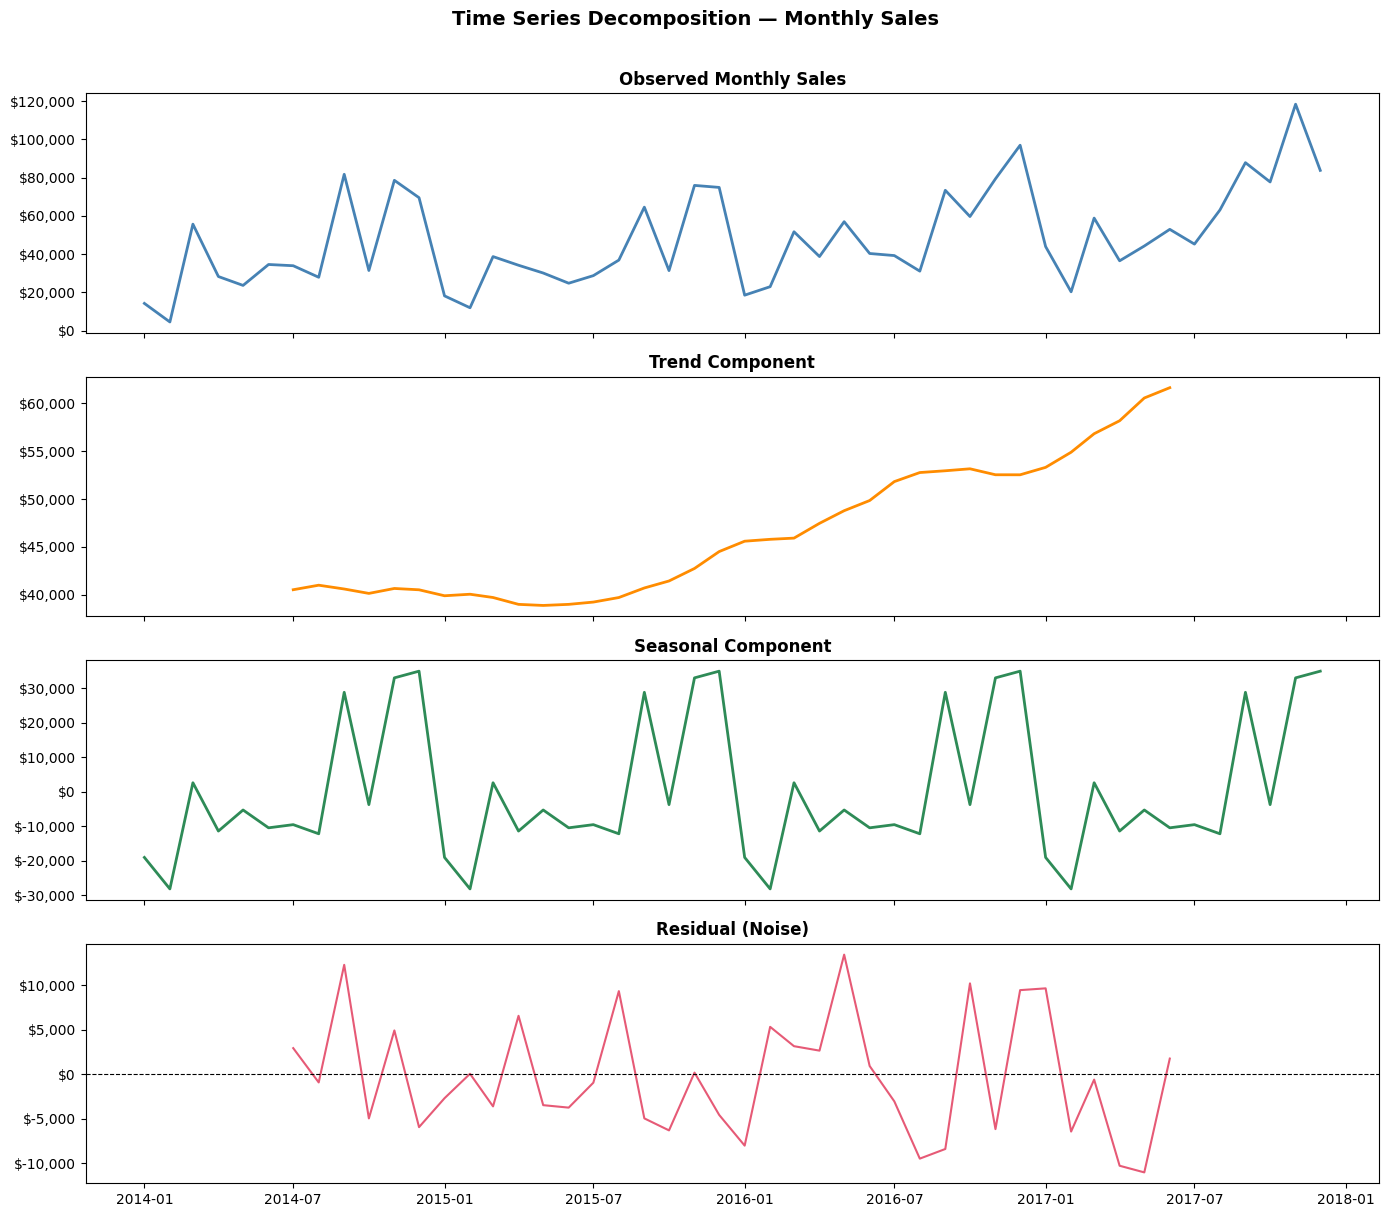

Saved.


In [3]:
# Plot all four components
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(monthly_sales, color="steelblue", linewidth=2)
axes[0].set_title("Observed Monthly Sales", fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

axes[1].plot(trend, color="darkorange", linewidth=2)
axes[1].set_title("Trend Component", fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

axes[2].plot(seasonal, color="seagreen", linewidth=2)
axes[2].set_title("Seasonal Component", fontweight="bold")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

axes[3].plot(residual, color="crimson", linewidth=1.5, alpha=0.7)
axes[3].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[3].set_title("Residual (Noise)", fontweight="bold")
axes[3].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.suptitle("Time Series Decomposition — Monthly Sales", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/time_series_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

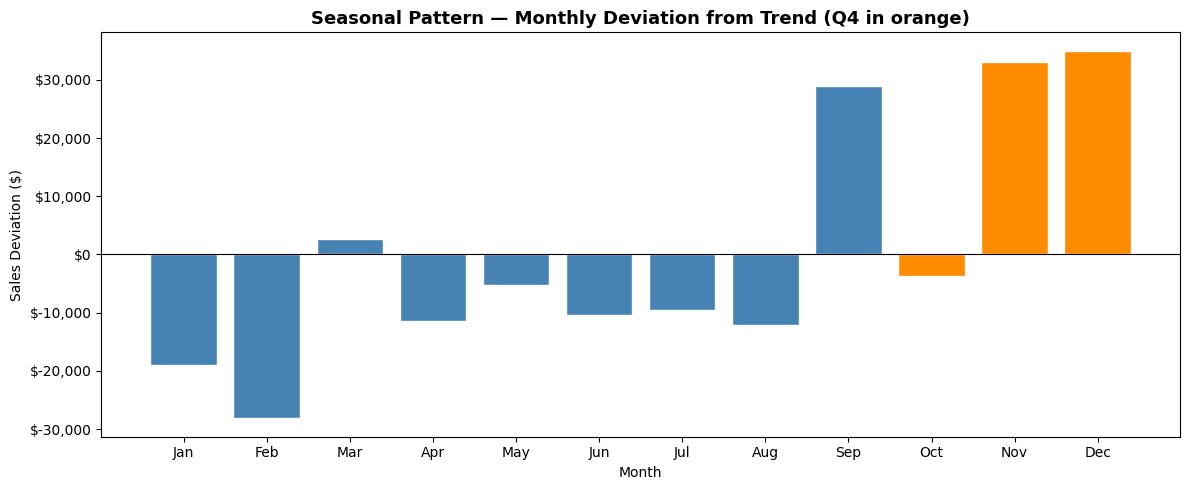

Saved.


In [4]:
# Plot seasonal pattern — what does a typical year look like?
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# Get one cycle of seasonal component
seasonal_cycle = seasonal[:12].values

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["darkorange" if i >= 9 else "steelblue" for i in range(12)]
ax.bar(month_labels, seasonal_cycle, color=colors, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Seasonal Pattern — Monthly Deviation from Trend (Q4 in orange)", 
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Sales Deviation ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("../outputs/figures/seasonal_pattern.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [5]:
# Trend growth analysis — how much has the business grown year over year?
trend_clean = trend.dropna()

# Get trend value at start and end of each year
yearly_trend = {}
for year in [2014, 2015, 2016, 2017]:
    year_data = trend_clean[trend_clean.index.year == year]
    if len(year_data) > 0:
        yearly_trend[year] = year_data.mean()

print("Average trend value by year:")
for year, val in yearly_trend.items():
    print(f"  {year}: ${val:,.0f}")

# Year-over-year growth
years = list(yearly_trend.keys())
for i in range(1, len(years)):
    growth = (yearly_trend[years[i]] - yearly_trend[years[i-1]]) / yearly_trend[years[i-1]] * 100
    print(f"\nTrend growth {years[i-1]} → {years[i]}: {growth:+.1f}%")

Average trend value by year:
  2014: $40,566
  2015: $40,400
  2016: $49,934
  2017: $57,578

Trend growth 2014 → 2015: -0.4%

Trend growth 2015 → 2016: +23.6%

Trend growth 2016 → 2017: +15.3%


In [6]:
# Residual analysis — are there any unusually large residuals worth investigating?
residual_clean = residual.dropna()
residual_std = residual_clean.std()
residual_mean = residual_clean.mean()

# Flag residuals beyond 2 standard deviations
anomalous = residual_clean[abs(residual_clean - residual_mean) > 2 * residual_std]

print(f"Residual mean: ${residual_mean:,.0f}")
print(f"Residual std:  ${residual_std:,.0f}")
print(f"\nMonths with unusually large residuals (>2 std devs):")
for date, val in anomalous.items():
    print(f"  {date.strftime('%Y-%m')}: ${val:,.0f}")

Residual mean: $-360
Residual std:  $6,691

Months with unusually large residuals (>2 std devs):
  2016-05: $13,460


In [7]:
# Save monthly sales series for use in forecasting notebook
monthly_df = monthly_sales.reset_index()
monthly_df.columns = ["ds", "y"]
monthly_df["ds"] = pd.to_datetime(monthly_df["ds"])

monthly_df.to_csv("../data/processed/monthly_sales.csv", index=False)
print("monthly_sales.csv saved — ready for Prophet forecasting.")
print("\nShape:", monthly_df.shape)
monthly_df.tail(6)

monthly_sales.csv saved — ready for Prophet forecasting.

Shape: (48, 2)


,ds,y
42,2017-07-01,45264.4160
43,2017-08-01,63120.8880
44,2017-09-01,87866.6520
45,2017-10-01,77776.9232
46,2017-11-01,118447.8250
47,2017-12-01,83829.3188
